# 전국 민간 아파트 분양가격 분석하기

## 사용 데이터
* 1) 전국평균 분양가격 (2013년12월~2015년8월): 각 지역별, 각 연월 별로 평당분양가격의 평균 값
* 2) 전국평균 분양가격 (2015년10월~2023년6월): 각 지역별, 각 연 별, 각 월 별, 각 규모 별로 제곱미터당분양가격의 평균 값

## 개요
* 서로 다른 format의 두 데이터를 가져와서 전처리 하고 병합하기
* 수치형 데이터와 범주형 데이터를 바라보는 시각을 기르기
* 데이터의 형식에 따른 다양한 시각화 방법 이해하기

## 다루는 내용
* groupby, melt, concat, pivot_table, transpose, info, describe, value_counts 등의 함수를 활용한 데이터 탐색 및 분석
* matplotlib과 seaborn의 barplot, lineplot, scatterplot, lmplot, heatmap, boxplot, swarm plot, distplot 등을 활용한 데이터 처리 및 시각화

# import

In [1]:
# 사용할 패키지를 import합니다
import sys
print('python', sys.version)

import numpy as np
print('numpy', np.__version__)

import pandas as pd
print('pandas', pd.__version__)

import matplotlib as mpl
print('matplotlib', mpl.__version__)

import matplotlib.pyplot as plt

import seaborn as sns
print('pandas', sns.__version__)

# 결과 확인을 용이하게 하기 위한 코드
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

# # 경고 메시지는 출력되지 않게 합니다.
# import warnings
# warnings.filterwarnings("ignore")

python 3.13.6 (tags/v3.13.6:4e66535, Aug  6 2025, 14:36:00) [MSC v.1944 64 bit (AMD64)]
numpy 2.4.2
pandas 3.0.1
matplotlib 3.10.8
pandas 0.13.2


# 데이터로드 및 확인

## df_2015 (~2015년)

In [ ]:
# (2013년12월~2015년8월) 분양가 파일을 로드해서 df_2015 라는 변수에 담습니다.
df_2015 = pd.read_csv("data/전국평균 분양가격 (2013년12월~2015년8월).csv", encoding="cp949") #default: sep=','

print('### 파일 확인하기')
type(df_2015)
df_2015
df_2015.shape #몇행,몇열인지 확인

df_2015.head() # 첫 5행
df_2015.tail() # 마지막 5행

### 파일 확인하기


pandas.DataFrame

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,...,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
0,서울,18189,17925,17925,18016,18098,19446,18867,18742,19274,...,20242,20269,20670,20670,19415,18842,18367,18374,18152,18443
1,부산,8111,8111,9078,8965,9402,9501,9453,9457,9411,...,9208,9208,9204,9235,9279,9327,9345,9515,9559,9581
2,대구,8080,8080,8077,8101,8267,8274,8360,8360,8370,...,8439,8253,8327,8416,8441,8446,8568,8542,8542,8795
3,인천,10204,10204,10408,10408,10000,9844,10058,9974,9973,...,10020,10020,10017,9876,9876,9938,10551,10443,10443,10449
4,광주,6098,7326,7611,7346,7346,7523,7659,7612,7622,...,7752,7748,7752,7756,7861,7914,7877,7881,8089,8231
5,대전,8321,8321,8321,8341,8341,8341,8333,8333,8333,...,8067,8067,8067,8067,8067,8145,8272,8079,8079,8079
6,울산,8090,8090,8090,8153,8153,8153,8153,8153,8493,...,8891,8891,8526,8526,8629,9380,9192,9190,9190,9215
7,경기,10855,10855,10791,10784,10876,10646,10266,10124,10134,...,10356,10379,10391,10355,10469,10684,10685,10573,10518,10573
8,세종,7601,7600,7532,7814,7908,7934,8067,8067,8141,...,8592,8560,8560,8560,8555,8546,8546,8671,8669,8695
9,강원,6230,6230,6230,6141,6373,6350,6350,6268,6268,...,6365,6365,6348,6350,6182,6924,6846,6986,7019,7008


(17, 22)

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,...,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
0,서울,18189,17925,17925,18016,18098,19446,18867,18742,19274,...,20242,20269,20670,20670,19415,18842,18367,18374,18152,18443
1,부산,8111,8111,9078,8965,9402,9501,9453,9457,9411,...,9208,9208,9204,9235,9279,9327,9345,9515,9559,9581
2,대구,8080,8080,8077,8101,8267,8274,8360,8360,8370,...,8439,8253,8327,8416,8441,8446,8568,8542,8542,8795
3,인천,10204,10204,10408,10408,10000,9844,10058,9974,9973,...,10020,10020,10017,9876,9876,9938,10551,10443,10443,10449
4,광주,6098,7326,7611,7346,7346,7523,7659,7612,7622,...,7752,7748,7752,7756,7861,7914,7877,7881,8089,8231


,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,...,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
12,전북,6282,6281,5946,5966,6277,6306,6351,6319,6436,...,6583,6583,6583,6583,6542,6551,6556,6601,6750,6580
13,전남,5678,5678,5678,5696,5736,5656,5609,5780,5685,...,5768,5784,5784,5833,5825,5940,6050,6243,6286,6289
14,경북,6168,6168,6234,6317,6412,6409,6554,6556,6563,...,6881,6989,6992,6953,6997,7006,6966,6887,7035,7037
15,경남,6473,6485,6502,6610,6599,6610,6615,6613,6606,...,7125,7332,7592,7588,7668,7683,7717,7715,7723,7665
16,제주,7674,7900,7900,7900,7900,7900,7914,7914,7914,...,7724,7739,7739,7739,7826,7285,7285,7343,7343,7343


## df_2023 (2015년10월~2023년6월)

In [3]:
df_2023 = pd.read_csv("data/전국평균 분양가격 (2015년10월~2023년6월).csv", encoding="cp949") #default: sep=','

print('### 파일 확인하기')
type(df_2023)
df_2023
df_2023.shape

df_2023.head() # 첫 5행
df_2023.tail() # 마지막 5행

### 파일 확인하기


pandas.DataFrame

,지역명,규모구분,연도,월,분양가격(제곱미터)
0,서울,모든면적,2015,10,5841
1,서울,전용면적 60제곱미터이하,2015,10,5652
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721
4,서울,전용면적 102제곱미터초과,2015,10,5879
...,...,...,...,...,...
7900,제주,모든면적,2023,6,7326
7901,제주,전용면적 60제곱미터이하,2023,6,7381
7902,제주,전용면적 60제곱미터초과 85제곱미터이하,2023,6,7084
7903,제주,전용면적 85제곱미터초과 102제곱미터이하,2023,6,6639


(7905, 5)

,지역명,규모구분,연도,월,분양가격(제곱미터)
0,서울,모든면적,2015,10,5841
1,서울,전용면적 60제곱미터이하,2015,10,5652
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721
4,서울,전용면적 102제곱미터초과,2015,10,5879


,지역명,규모구분,연도,월,분양가격(제곱미터)
7900,제주,모든면적,2023,6,7326
7901,제주,전용면적 60제곱미터이하,2023,6,7381
7902,제주,전용면적 60제곱미터초과 85제곱미터이하,2023,6,7084
7903,제주,전용면적 85제곱미터초과 102제곱미터이하,2023,6,6639
7904,제주,전용면적 102제곱미터초과,2023,6,7506


# 앞으로 수행할 데이터시각화 결과

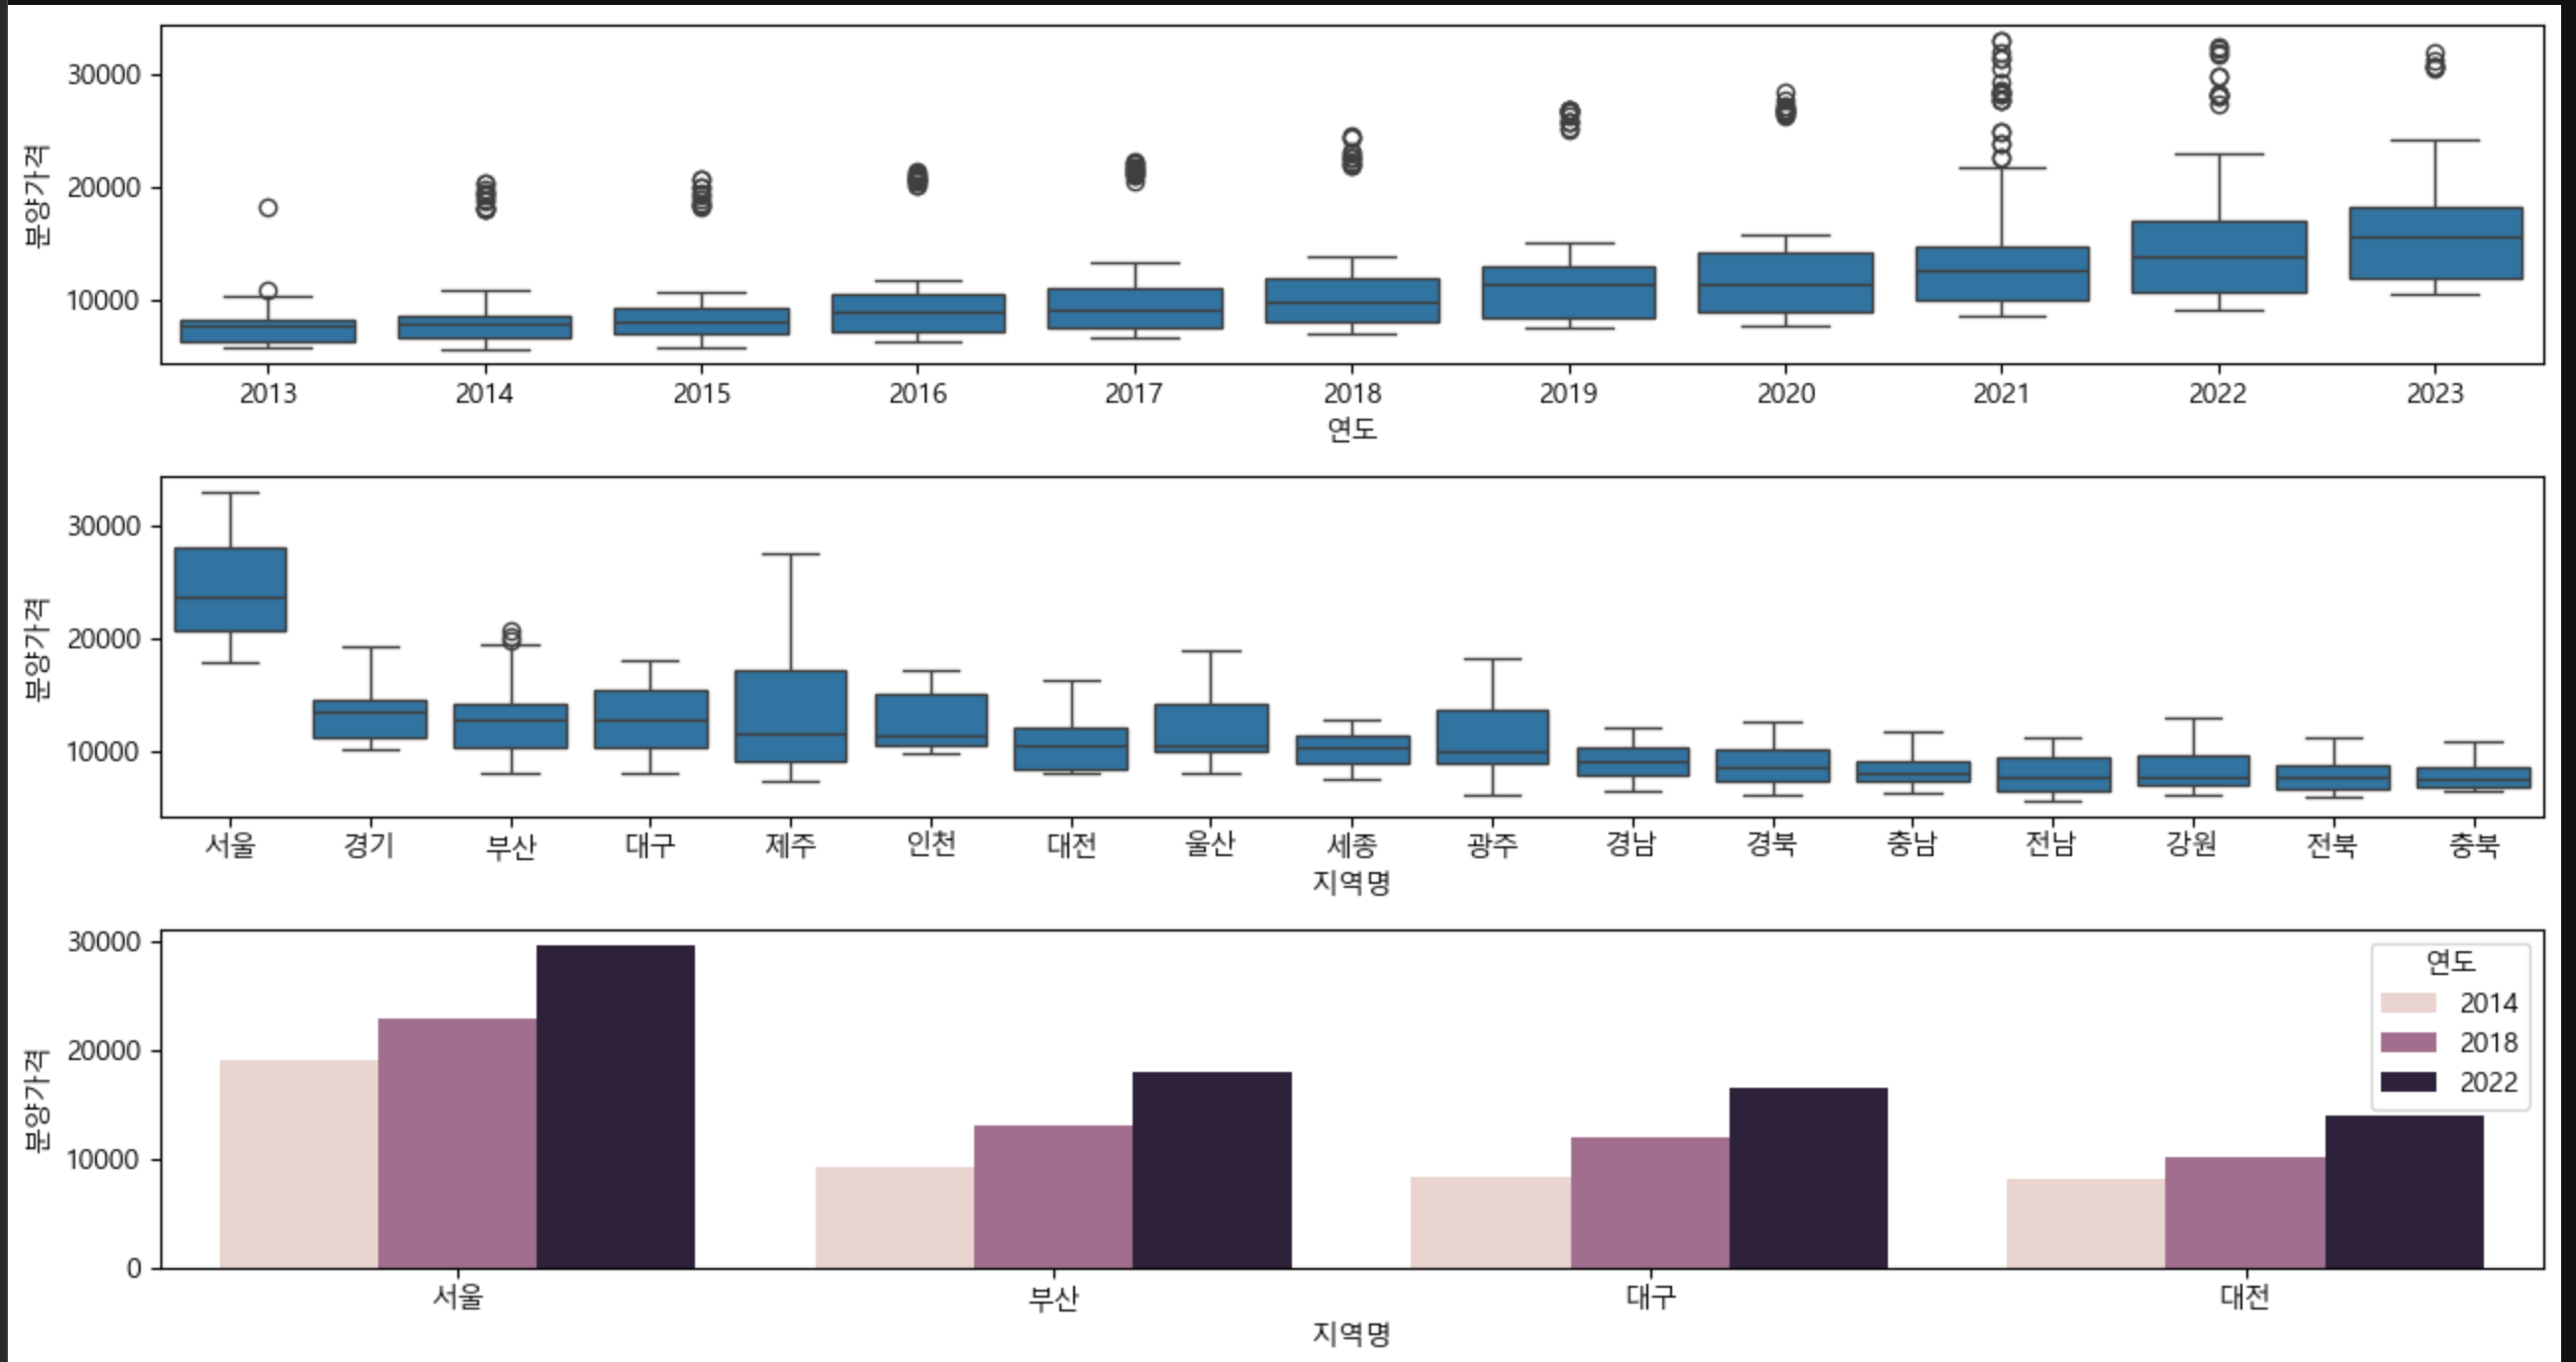

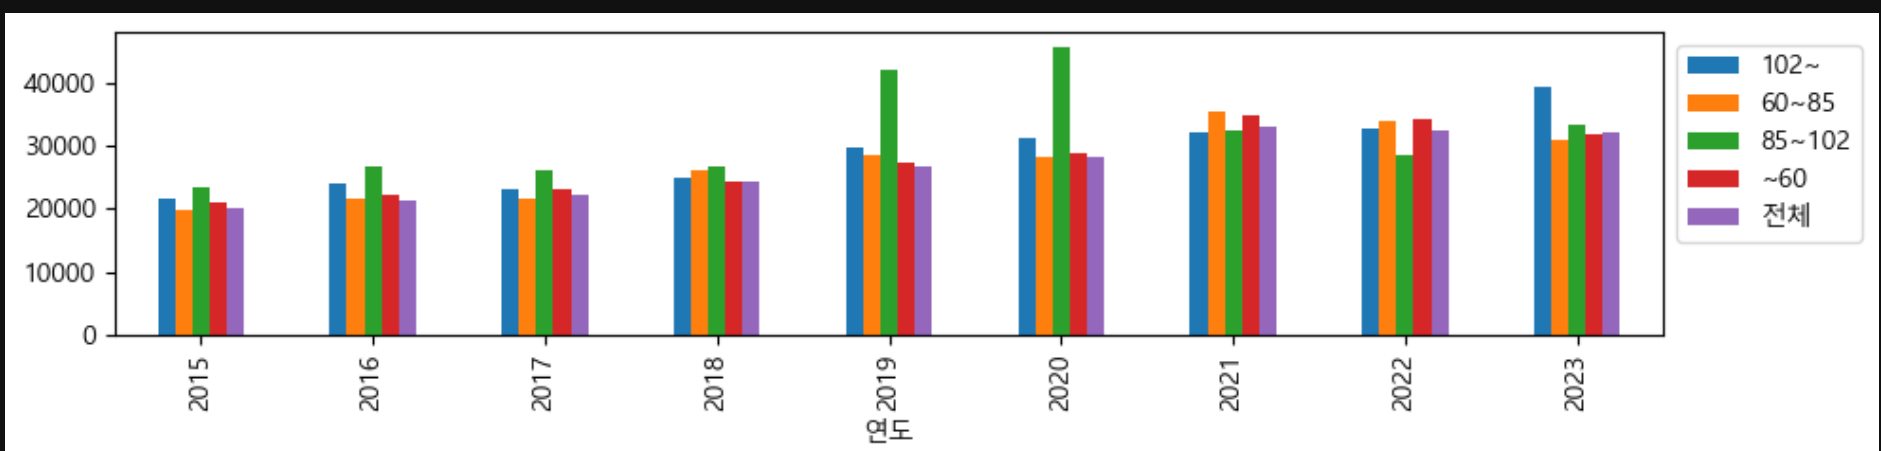

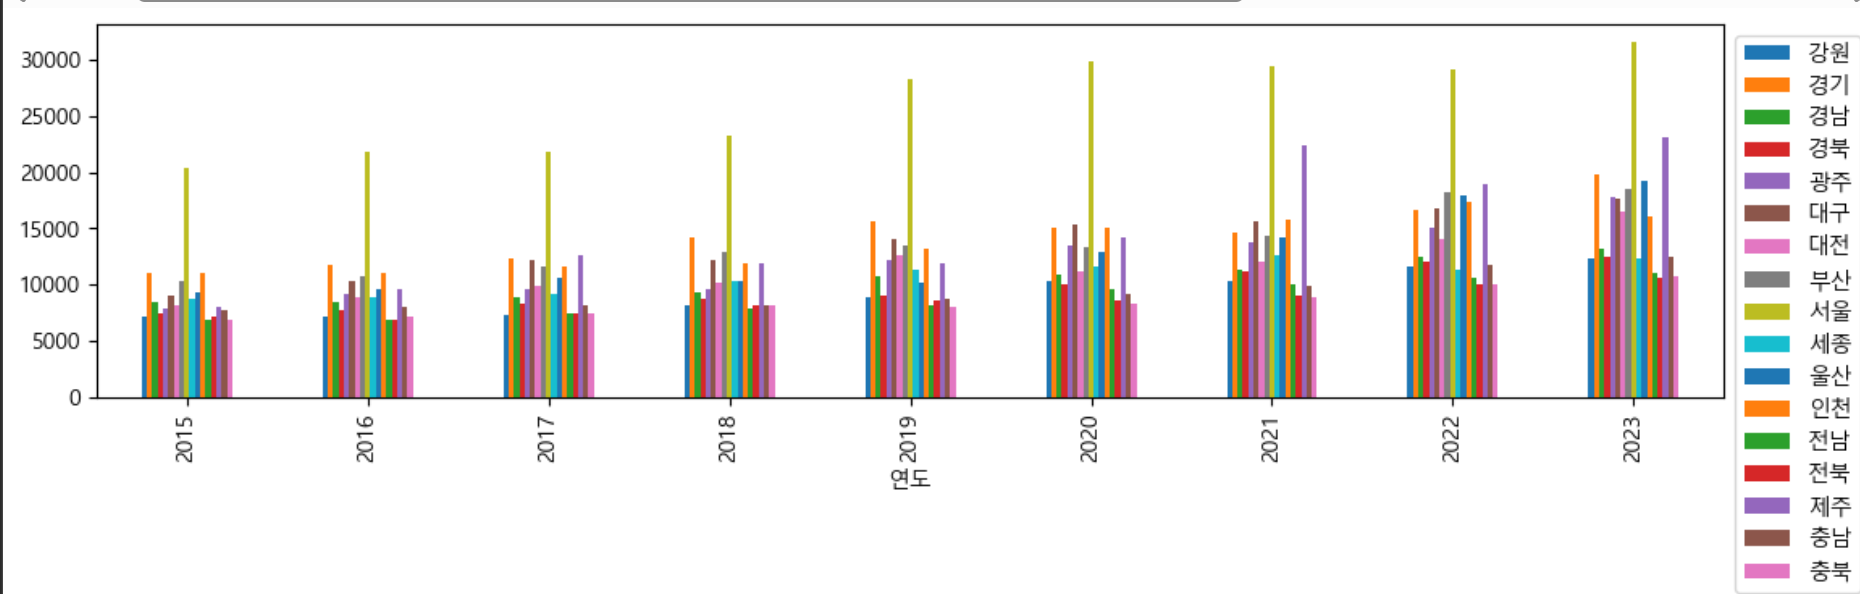

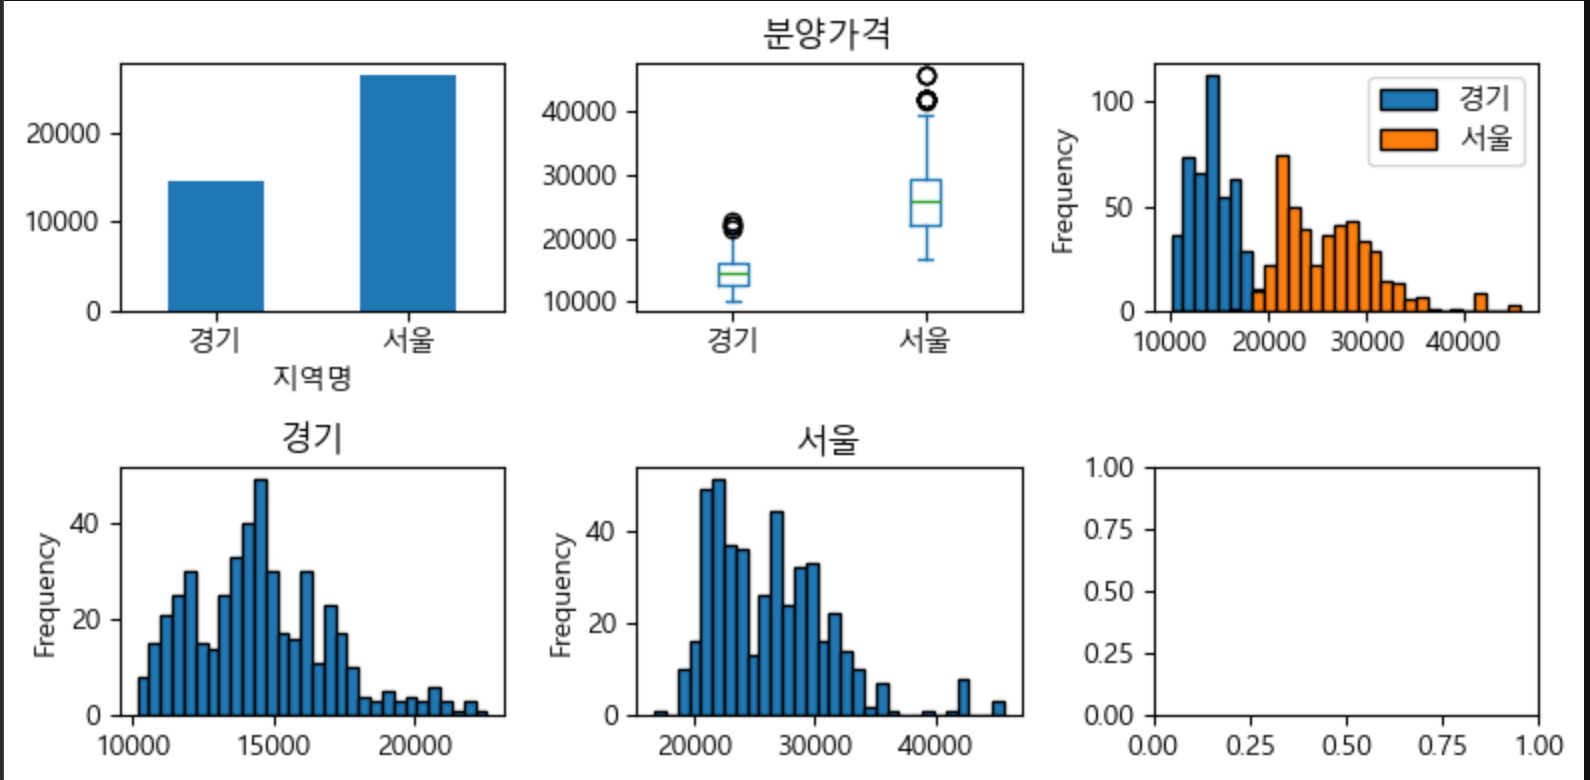

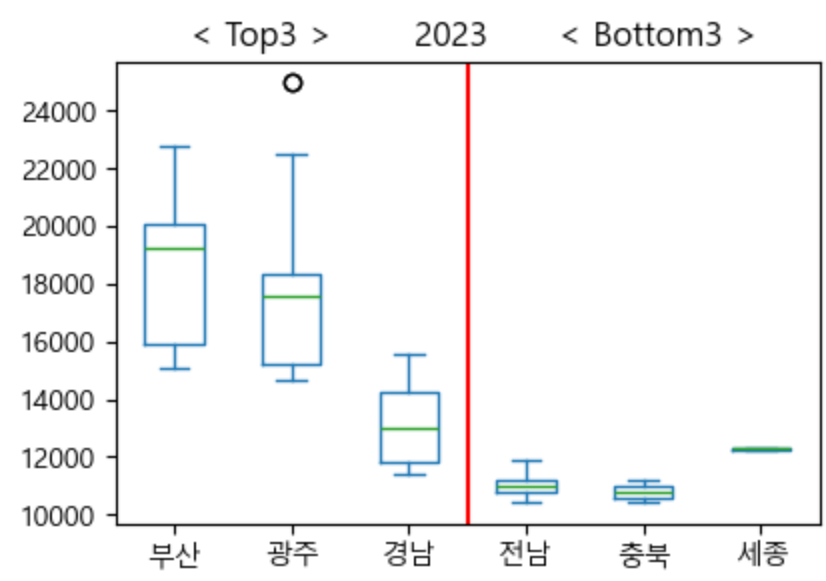

# ====== 이번주 수업내용 ======

In [ ]:
####### df_2023 전처리하기
df_2023 = pd.read_csv("data/전국평균 분양가격 (2015년10월~2023년6월).csv", encoding="cp949") #default: sep=','
df_2023.head()
df_2023.info()

### ==> 1) '분양가격(제곱미터)'column: nan(결측치) 제거
df_2023_nn=df_2023.loc[df_2023['분양가격(제곱미터)'].notnull()]
#분양가격이 notnull인것만 모아서 다시저장

# ### ==> 2) '분양가격(제곱미터)'column: 숫자로 구성된 문자 -> float형 | 숫자가 아닌 문자 -> nan으로 변경 후 행 제거
df_2023_ft=df_2023_nn.copy()
df_2023_ft['분양가격(제곱미터)']=pd.to_numeric(df_2023_ft['분양가격(제곱미터)'], errors='coerce')
df_2023_ft=df_2023_ft.loc[df_2023_ft['분양가격(제곱미터)'].notnull()]

### ==> 3) '분양가격(제곱미터)'을  '평당분양가격'으로 변환하기
df_2023_ft["평당분양가격"]=df_2023_ft['분양가격(제곱미터)'] * 3.3
df_prep=df_2023_ft.drop(columns=['분양가격(제곱미터)'], errors='ignore')# '분양가격(제곱미터)'' column이 없는 경우 error raise 방지

### ==> 4) '규모구분'을 '전용면적'으로 변환하기
def parse_area_only(x):
    x2=x.replace("모든면적", "전체").replace("전용면적", "").replace("제곱미터", "").replace("60이하", "~60")
    x3=x2.replace("초과", "~").replace("이하", "").replace(" ", "")
    return x3
    
df_prep["전용면적"] = df_prep["규모구분"].map(parse_area_only)
df_prep=df_prep.drop(columns=['규모구분'], errors='ignore') # '규모구분' column이 없는 경우 error raise 방지

## ==> 5) reset_index 후 전처리한 데이터 확인하기
df_prep=df_prep.reset_index(drop=True)

df_prep.head()
df_prep.info()

,지역명,규모구분,연도,월,분양가격(제곱미터)
0,서울,모든면적,2015,10,5841
1,서울,전용면적 60제곱미터이하,2015,10,5652
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721
4,서울,전용면적 102제곱미터초과,2015,10,5879


<class 'pandas.DataFrame'>
RangeIndex: 7905 entries, 0 to 7904
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   지역명         7905 non-null   str  
 1   규모구분        7905 non-null   str  
 2   연도          7905 non-null   int64
 3   월           7905 non-null   int64
 4   분양가격(제곱미터)  7358 non-null   str  
dtypes: int64(2), str(3)
memory usage: 308.9 KB


,지역명,연도,월,평당분양가격,전용면적
0,서울,2015,10,19275.3,전체
1,서울,2015,10,18651.6,~60
2,서울,2015,10,19410.6,60~85
3,서울,2015,10,18879.3,85~102
4,서울,2015,10,19400.7,102~


<class 'pandas.DataFrame'>
RangeIndex: 7322 entries, 0 to 7321
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   지역명     7322 non-null   str    
 1   연도      7322 non-null   int64  
 2   월       7322 non-null   int64  
 3   평당분양가격  7322 non-null   float64
 4   전용면적    7322 non-null   str    
dtypes: float64(1), int64(2), str(2)
memory usage: 286.1 KB


# => 1) '분양가격(제곱미터)'column: nan(결측치) 제거

## 데이터 요약 및 확인하기 (info)

In [5]:
df_2023 = pd.read_csv("data/전국평균 분양가격 (2015년10월~2023년6월).csv", encoding="cp949") #default: sep=','
df_2023.shape
df_2023.info()

(7905, 5)

<class 'pandas.DataFrame'>
RangeIndex: 7905 entries, 0 to 7904
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   지역명         7905 non-null   str  
 1   규모구분        7905 non-null   str  
 2   연도          7905 non-null   int64
 3   월           7905 non-null   int64
 4   분양가격(제곱미터)  7358 non-null   str  
dtypes: int64(2), str(3)
memory usage: 308.9 KB


## 결측치 np.nan

In [6]:
sr1=pd.Series(['NaN', np.nan, 1, 2, 3.1])
sr1

for v1 in sr1:
    v1, type(v1)

## np.nan 체크 방법
v2=np.nan
print('## 잘못된 방법')
v2==np.nan 

print('## 올바른 방법')
v2!=v2

## series에서 np.nan 확인 함수 isnull()
sr1.isnull()

0    NaN
1    NaN
2      1
3      2
4    3.1
dtype: object

('NaN', str)

(nan, float)

(1, int)

(2, int)

...

## 잘못된 방법


False

## 올바른 방법


True

0    False
1     True
2    False
3    False
4    False
dtype: bool

## 결측치 확인하기

In [ ]:
# df_2023 변수의 nan을 체크
df_2023
df_2023['분양가격(제곱미터)'].isnull()

# column 별 결측치 개수
df_2023.isnull().sum()# axis=0


,지역명,규모구분,연도,월,분양가격(제곱미터)
0,서울,모든면적,2015,10,5841
1,서울,전용면적 60제곱미터이하,2015,10,5652
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721
4,서울,전용면적 102제곱미터초과,2015,10,5879
...,...,...,...,...,...
7900,제주,모든면적,2023,6,7326
7901,제주,전용면적 60제곱미터이하,2023,6,7381
7902,제주,전용면적 60제곱미터초과 85제곱미터이하,2023,6,7084
7903,제주,전용면적 85제곱미터초과 102제곱미터이하,2023,6,6639


0       False
1       False
2       False
3       False
4       False
        ...  
7900    False
7901    False
7902    False
7903    False
7904    False
Name: 분양가격(제곱미터), Length: 7905, dtype: bool

지역명             0
규모구분            0
연도              0
월               0
분양가격(제곱미터)    547
dtype: int64

## 결측치 핸들링하기

In [32]:
#분양가격이 nan인 행만 가져오기
bool_ind=df_2023['분양가격(제곱미터)'].isnull()
df2=df_2023.loc[bool_ind]
df2

## 혹시 특정 "지역명"에 nan이 있나?
df2['지역명'].value_counts()

# df2의 nan 모두 -1로 바꾸기
df3=df2.fillna('-99') 
df3 # 한번 해보기, 추후 분석에 사용하지는 않음
    
## nan이 없는 행만 가져오기
df_2023_nn=df_2023[df_2023['분양가격(제곱미터)'].notnull()]
df_2023_nn # 추후 분석에 사용

,지역명,규모구분,연도,월,분양가격(제곱미터)
368,광주,전용면적 85제곱미터초과 102제곱미터이하,2016,2,NaN
369,광주,전용면적 102제곱미터초과,2016,2,NaN
374,대전,전용면적 102제곱미터초과,2016,2,NaN
388,강원,전용면적 85제곱미터초과 102제곱미터이하,2016,2,NaN
421,제주,전용면적 60제곱미터이하,2016,2,NaN
...,...,...,...,...,...
7848,광주,전용면적 85제곱미터초과 102제곱미터이하,2023,6,NaN
7853,대전,전용면적 85제곱미터초과 102제곱미터이하,2023,6,NaN
7863,세종,전용면적 85제곱미터초과 102제곱미터이하,2023,6,NaN
7864,세종,전용면적 102제곱미터초과,2023,6,NaN


지역명
울산    128
대전    110
세종     74
광주     70
제주     65
경북     22
충남     19
강원     12
전남     11
대구      9
경남      9
서울      6
전북      4
인천      4
충북      2
부산      2
Name: count, dtype: int64

,지역명,규모구분,연도,월,분양가격(제곱미터)
368,광주,전용면적 85제곱미터초과 102제곱미터이하,2016,2,-99
369,광주,전용면적 102제곱미터초과,2016,2,-99
374,대전,전용면적 102제곱미터초과,2016,2,-99
388,강원,전용면적 85제곱미터초과 102제곱미터이하,2016,2,-99
421,제주,전용면적 60제곱미터이하,2016,2,-99
...,...,...,...,...,...
7848,광주,전용면적 85제곱미터초과 102제곱미터이하,2023,6,-99
7853,대전,전용면적 85제곱미터초과 102제곱미터이하,2023,6,-99
7863,세종,전용면적 85제곱미터초과 102제곱미터이하,2023,6,-99
7864,세종,전용면적 102제곱미터초과,2023,6,-99


,지역명,규모구분,연도,월,분양가격(제곱미터)
0,서울,모든면적,2015,10,5841
1,서울,전용면적 60제곱미터이하,2015,10,5652
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721
4,서울,전용면적 102제곱미터초과,2015,10,5879
...,...,...,...,...,...
7900,제주,모든면적,2023,6,7326
7901,제주,전용면적 60제곱미터이하,2023,6,7381
7902,제주,전용면적 60제곱미터초과 85제곱미터이하,2023,6,7084
7903,제주,전용면적 85제곱미터초과 102제곱미터이하,2023,6,6639


## <실습1>
* (기본) 3w_f1.txt 파일을 읽은 후 결측치를 모두 0으로 채우시오
* (심화) 3w_f1.txt 'c1' column 값이 'A' 인 행의 결측치만 '-'로 채우시오

In [37]:
df1=pd.read_table('data/3w_f1.txt', sep='\t', index_col=0)
df1

print('## 기본')
## 코드 작성 ##

df2

print('## 심화')
## 코드 작성 ##
## 힌트: df1['c1']=='A' 인 df, df1['c1']!='A' df 로 나누기.  pd.concat, sort_index 사용

df3


,c1,c2,c3,c4
1,A,20.0,NaN,30.0
2,B,40.0,20.0,NaN
3,A,NaN,40.0,NaN
4,A,30.0,NaN,20.0
5,C,NaN,40.0,20.0
6,B,30.0,30.0,NaN


## 기본


,c1,c2,c3,c4
1,A,20.0,0.0,30.0
2,B,40.0,20.0,0.0
3,A,0.0,40.0,0.0
4,A,30.0,0.0,20.0
5,C,0.0,40.0,20.0
6,B,30.0,30.0,0.0


## 심화


,c1,c2,c3,c4
1,A,20.0,-,30.0
2,B,40.0,20.0,+
3,A,-,40.0,-
4,A,30.0,-,20.0
5,C,+,40.0,20.0
6,B,30.0,30.0,+


# => 2) '분양가격(제곱미터)'column: 숫자로 구성된 문자 -> float형 ||| 숫자가 아닌 문자 -> nan으로 변경 후 행 제거

## 데이터 type 확인 (왜 분양가격데이터 type이 object이지?)

In [39]:
df_2023_nn.info() 
df_2023_nn.head(3)
# ==> 지역명, 규모구분, 분양가격(제곱미터) column: object type

print('object type:')
print('1) 모든 element가 문자(str) dtype일 경우')
print('2) str dtype과 다른 dype (int, float등)이 섞여있을 경우')

<class 'pandas.core.frame.DataFrame'>
Index: 7358 entries, 0 to 7904
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   지역명         7358 non-null   object
 1   규모구분        7358 non-null   object
 2   연도          7358 non-null   int64 
 3   월           7358 non-null   int64 
 4   분양가격(제곱미터)  7358 non-null   object
dtypes: int64(2), object(3)
memory usage: 344.9+ KB


,지역명,규모구분,연도,월,분양가격(제곱미터)
0,서울,모든면적,2015,10,5841
1,서울,전용면적 60제곱미터이하,2015,10,5652
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882


object type:
1) 모든 element가 문자(str) dtype일 경우
2) str dtype과 다른 dype (int, float등)이 섞여있을 경우


## <실습2>
* 아래의 l1, l2, l3, l4, l5, l6를 data로 갖는 series를 만들고 각 series의 type을 확인해보시오

In [21]:
l1=[123,234,123]
l2=['ab','cd','ef', 'ge']
l3=[123,234,'123']
l4=[2, 3, np.nan]
l5=[123,234,345, ' ']
l6=['ab','cd','ef', np.nan]

## 코드작성
s1=pd.Series(l6)
s1
pd.to_numeric(s1,errors='coerce')

0     ab
1     cd
2     ef
3    NaN
dtype: str

0   NaN
1   NaN
2   NaN
3   NaN
dtype: float64

In [ ]:
df_2023_nn['분양가격(제곱미터)'].iloc[:3]


0    5841
1    5652
2    5882
Name: 분양가격(제곱미터), dtype: str

## 분양가격 column에 등장하는 값과 dtype 확인

In [41]:
for x in df_2023_nn['분양가격(제곱미터)'].iloc[:3]:
    x, type(x)

## cf) 연도 column
for x in df_2023_nn['연도'].iloc[:3]:
    x, type(x)
    

('5841', str)

('5652', str)

('5882', str)

(2015, int)

(2015, int)

(2015, int)

## '분양가격(제곱미터)' 컬럼의 type을 float type으로 변환

In [43]:
# 문자열의 덧셈은 문자열 연결
a='123'
b='456'
a+b
c=123
d=456
c+d

'123456'

579

In [45]:
pd.to_numeric(df_2023_nn['분양가격(제곱미터)'])

ValueError: Unable to parse string "  " at position 28

### 분양가격 column에 등장하는 값 중 숫자로 이뤄지지 않은 값 확인

In [47]:
invalid_val_list=[]
for x in df_2023_nn["분양가격(제곱미터)"]:
    if x.isdigit():
        continue
    invalid_val_list.append(x)

set(invalid_val_list)# ==> ' ', '  '이 포함

{' ', '  '}

### 숫자가 아닌 값 (' ','  ') 에는 np.nan을 넣고, 숫자로 구성된 값은 float로 형 변환

#### to_numeric()

In [49]:
## to_numeric 함수
t1=pd.Series(['12','12*#','45.6','a b',np.nan,'1,234', ' ', '  '])
t1
t2=pd.to_numeric(t1, errors='coerce') # 숫자료 변경이 불가능한 값은 np.nan으로 변경됨
t2
t2=pd.to_numeric(t1, errors='raise') # 숫자료 변경이 불가능한 값이 있으면 error 생성 (default)
t2

0       12
1     12*#
2     45.6
3      a b
4      NaN
5    1,234
6         
7         
dtype: object

0    12.0
1     NaN
2    45.6
3     NaN
4     NaN
5     NaN
6     NaN
7     NaN
dtype: float64

ValueError: Unable to parse string "12*#" at position 1

In [51]:
## 분양가격 type을 float로 변경
df_2023_ft=df_2023_nn.copy()  ## dataframe 복사: 주소복사가 아닌 데이터 자체 복사히 사용
df_2023_ft['분양가격(제곱미터)']=pd.to_numeric(df_2023_nn['분양가격(제곱미터)'], errors='coerce')
df_2023_ft.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7358 entries, 0 to 7904
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   지역명         7358 non-null   object 
 1   규모구분        7358 non-null   object 
 2   연도          7358 non-null   int64  
 3   월           7358 non-null   int64  
 4   분양가격(제곱미터)  7322 non-null   float64
dtypes: float64(1), int64(2), object(2)
memory usage: 344.9+ KB


#### map함수 활용

In [22]:
def str_to_float(x):
    if x.isdigit():
        return float(x)
    return np.nan

df_2023_ft=df_2023_nn.copy()
df_2023_ft['분양가격(제곱미터)']=df_2023_nn['분양가격(제곱미터)'].map(str_to_float)
df_2023_ft.info()

<class 'pandas.DataFrame'>
Index: 7358 entries, 0 to 7904
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   지역명         7358 non-null   str    
 1   규모구분        7358 non-null   str    
 2   연도          7358 non-null   int64  
 3   월           7358 non-null   int64  
 4   분양가격(제곱미터)  7322 non-null   float64
dtypes: float64(1), int64(2), str(2)
memory usage: 344.9 KB


## 분양가격이 nan인 행 제거

In [55]:
## 분양가격이 nan인 행을 제거한 최종 df
df_2023_ft=df_2023_ft.loc[df_2023_ft['분양가격(제곱미터)'].notnull()]
df_2023_ft.shape

(7322, 5)

## <실습3>
## 시험문제에 똑같이 나옴!!
* sr1은 int형과 str형 값들이 들어있다. 값이
* 1) int형 또는
  2) 숫자로만 구성된 str형
* 인 경우 1000을 더한 값을, 그렇지 않은 경우 그대로의 값을 갖는 sr2를 출력하시오
* 힌트) map(),  isdigit()

In [29]:
sr1=pd.Series([10, '20', 30, 'ab', 40, '50k'])

## 코드 작성 ##
def func1(x):
    if type(x) == int:
        return x+1000
    elif x.isdigit():
        return int(x)+1000
    else:
        return x

sr2=sr1.map(func1)
sr1
sr2


0     10
1     20
2     30
3     ab
4     40
5    50k
dtype: object

0    1010
1    1020
2    1030
3      ab
4    1040
5     50k
dtype: object

# => 3) '분양가격(제곱미터)'을  '평당분양가격'으로 변환하기

In [58]:
df_2023_ft
df_2023_ft["평당분양가격"]=df_2023_ft['분양가격(제곱미터)'] * 3.3
df_prep=df_2023_ft.drop(columns=['분양가격(제곱미터)'], errors='ignore')# '분양가격(제곱미터)'' column이 없는 경우 error raise 방지
df_prep

,지역명,규모구분,연도,월,분양가격(제곱미터)
0,서울,모든면적,2015,10,5841.0
1,서울,전용면적 60제곱미터이하,2015,10,5652.0
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882.0
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721.0
4,서울,전용면적 102제곱미터초과,2015,10,5879.0
...,...,...,...,...,...
7900,제주,모든면적,2023,6,7326.0
7901,제주,전용면적 60제곱미터이하,2023,6,7381.0
7902,제주,전용면적 60제곱미터초과 85제곱미터이하,2023,6,7084.0
7903,제주,전용면적 85제곱미터초과 102제곱미터이하,2023,6,6639.0


,지역명,규모구분,연도,월,평당분양가격
0,서울,모든면적,2015,10,19275.3
1,서울,전용면적 60제곱미터이하,2015,10,18651.6
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,19410.6
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,18879.3
4,서울,전용면적 102제곱미터초과,2015,10,19400.7
...,...,...,...,...,...
7900,제주,모든면적,2023,6,24175.8
7901,제주,전용면적 60제곱미터이하,2023,6,24357.3
7902,제주,전용면적 60제곱미터초과 85제곱미터이하,2023,6,23377.2
7903,제주,전용면적 85제곱미터초과 102제곱미터이하,2023,6,21908.7


# => 4) '규모구분'을 '전용면적'으로 변환하기

In [60]:
def parse_area_only(x):
    x2=x.replace("모든면적", "전체").replace("전용면적", "").replace("제곱미터", "").replace("60이하", "~60")
    x3=x2.replace("초과", "~").replace("이하", "").replace(" ", "")
    return x3

#df_prep2=df_prep.copy()
df_prep["전용면적"] = df_prep["규모구분"].map(parse_area_only)
df_prep

,지역명,규모구분,연도,월,평당분양가격,전용면적
0,서울,모든면적,2015,10,19275.3,전체
1,서울,전용면적 60제곱미터이하,2015,10,18651.6,~60
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,19410.6,60~85
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,18879.3,85~102
4,서울,전용면적 102제곱미터초과,2015,10,19400.7,102~
...,...,...,...,...,...,...
7900,제주,모든면적,2023,6,24175.8,전체
7901,제주,전용면적 60제곱미터이하,2023,6,24357.3,~60
7902,제주,전용면적 60제곱미터초과 85제곱미터이하,2023,6,23377.2,60~85
7903,제주,전용면적 85제곱미터초과 102제곱미터이하,2023,6,21908.7,85~102


## cf) series.str.replace 사용

In [68]:
sr1=pd.Series(['ab','cd','ad'])
sr1

'### series.replace'
sr1.replace('a','-')
sr1.replace('ab','-')

'### series.str.replace'
sr1.str.replace('a','-')

0    ab
1    cd
2    ad
dtype: object

'### series.replace'

0    ab
1    cd
2    ad
dtype: object

0     -
1    cd
2    ad
dtype: object

'### series.str.replace'

0    -b
1    cd
2    -d
dtype: object

## '규모구분' column 제거

In [70]:
df_prep=df_prep.drop(columns=['규모구분'], errors='ignore') # '규모구분' column이 없는 경우 error raise 방지
df_prep

,지역명,연도,월,평당분양가격,전용면적
0,서울,2015,10,19275.3,전체
1,서울,2015,10,18651.6,~60
2,서울,2015,10,19410.6,60~85
3,서울,2015,10,18879.3,85~102
4,서울,2015,10,19400.7,102~
...,...,...,...,...,...
7900,제주,2023,6,24175.8,전체
7901,제주,2023,6,24357.3,~60
7902,제주,2023,6,23377.2,60~85
7903,제주,2023,6,21908.7,85~102


## <실습4>
* 주어진 series의 모든 'a'는 *로 모든'b'는 $로 바꾸시오
* map과 str.replace를 각각 사용하여 바꾸시오

In [72]:
sr1=pd.Series(['abc', 'cde', 'aaa', 'bb_','10'])
sr1

## map

## str.replace


0    abc
1    cde
2    aaa
3    bb_
4     10
dtype: object

0    *$c
1    cde
2    ***
3    $$_
4     10
dtype: object

0    *$c
1    cde
2    ***
3    $$_
4     10
dtype: object

# ==> 5) reset_index 후 전처리 한 데이터 확인하기

In [72]:
df_prep.info()
df_prep.reset_index()
df_prep.reset_index(drop=True)
df_prep=df_prep.reset_index(drop=True)
df_prep.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7322 entries, 0 to 7904
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   지역명     7322 non-null   object 
 1   연도      7322 non-null   int64  
 2   월       7322 non-null   int64  
 3   평당분양가격  7322 non-null   float64
 4   전용면적    7322 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 343.2+ KB


,index,지역명,연도,월,평당분양가격,전용면적
0,0,서울,2015,10,19275.3,전체
1,1,서울,2015,10,18651.6,~60
2,2,서울,2015,10,19410.6,60~85
3,3,서울,2015,10,18879.3,85~102
4,4,서울,2015,10,19400.7,102~
...,...,...,...,...,...,...
7317,7900,제주,2023,6,24175.8,전체
7318,7901,제주,2023,6,24357.3,~60
7319,7902,제주,2023,6,23377.2,60~85
7320,7903,제주,2023,6,21908.7,85~102


,지역명,연도,월,평당분양가격,전용면적
0,서울,2015,10,19275.3,전체
1,서울,2015,10,18651.6,~60
2,서울,2015,10,19410.6,60~85
3,서울,2015,10,18879.3,85~102
4,서울,2015,10,19400.7,102~
...,...,...,...,...,...
7317,제주,2023,6,24175.8,전체
7318,제주,2023,6,24357.3,~60
7319,제주,2023,6,23377.2,60~85
7320,제주,2023,6,21908.7,85~102


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7322 entries, 0 to 7321
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   지역명     7322 non-null   object 
 1   연도      7322 non-null   int64  
 2   월       7322 non-null   int64  
 3   평당분양가격  7322 non-null   float64
 4   전용면적    7322 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 286.1+ KB


# 실습 풀이

## <실습1>
* (기본) 3w_f1.txt 파일을 읽은 후 결측치를 모두 0으로 채우시오
* (심화) 3w_f1.txt 'c1' column 값이 'A' 인 행의 결측치는 '-'로, 'A'가 아닌 행의 결측치는 '+'로 채우시오

In [68]:
df1=pd.read_table('data/3w_f1.txt', sep='\t', index_col=0)
df1

print('## 기본')
## 코드 작성 ##
df2=df1.fillna(0)
## 코드 작성 끝 ##
df2

print('## 심화')
## 코드 작성 ##
## 힌트: df1['c1']=='A' 인 df, df1['c1']!='A' df 로 나누기.  pd.concat, sort_index 사용
df3a=df1.loc[df1['c1']=='A']
df3b=df1.loc[df1['c1']!='A']
df3a=df3a.fillna('-')
df3b=df3b.fillna('+')

df3=pd.concat([df3a, df3b]).sort_index()
## 코드 작성 끝 ##
df3


,c1,c2,c3,c4
1,A,20.0,NaN,30.0
2,B,40.0,20.0,NaN
3,A,NaN,40.0,NaN
4,A,30.0,NaN,20.0
5,C,NaN,40.0,20.0
6,B,30.0,30.0,NaN


## 기본


,c1,c2,c3,c4
1,A,20.0,0.0,30.0
2,B,40.0,20.0,0.0
3,A,0.0,40.0,0.0
4,A,30.0,0.0,20.0
5,C,0.0,40.0,20.0
6,B,30.0,30.0,0.0


## 심화


,c1,c2,c3,c4
1,A,20.0,-,30.0
2,B,40.0,20.0,+
3,A,-,40.0,-
4,A,30.0,-,20.0
5,C,+,40.0,20.0
6,B,30.0,30.0,+


## <실습2>
* 아래의 l1, l2, l3, l4, l5, l6를 data로 갖는 series를 만들고 각 series의 type을 확인해보시오

In [15]:
l1=[123,234,123]
l2=['ab','cd','ef', 'ge']
l3=[123,234,'123']
l4=[2, 3, np.nan]
l5=[123,234,345, ' ']
l6=['ab','cd','ef', np.nan]

## 코드작성
sr1=pd.Series(l1)
sr1
sr2=pd.Series(l2)
sr2
sr3=pd.Series(l3)
sr3
sr4=pd.Series(l4)
sr4
sr5=pd.Series(l5)
sr5
sr6=pd.Series(l6)
sr6

0    123
1    234
2    123
dtype: int64

0    ab
1    cd
2    ef
3    ge
dtype: object

0    123
1    234
2    123
dtype: object

0    2.0
1    3.0
2    NaN
dtype: float64

0    123
1    234
2    345
3       
dtype: object

0     ab
1     cd
2     ef
3    NaN
dtype: object

## <실습3>
* sr1은 int형과 str형 값들이 들어있다. 값이
* 1) int형 또는
  2) 숫자로만 구성된 str형
* 인 경우 1000을 더한 값을, 그렇지 않은 경우 그대로의 값을 갖는 sr2를 출력하시오
* 힌트) map(),  isdigit()

In [56]:
sr1=pd.Series([10, '20', 30, 'ab', 40, '50k'])

## 코드 작성 ##
def func1(x):
    print(x)
    if type(x)==int:
        return x+1000
    elif x.isdigit():
        return int(x)+1000
    else:
        return x
    
sr2=sr1.map(func1)
sr1
sr2

10
20
30
ab
40
50k


0     10
1     20
2     30
3     ab
4     40
5    50k
dtype: object

0    1010
1    1020
2    1030
3      ab
4    1040
5     50k
dtype: object

## <실습4>
* 주어진 series의 모든 'a'는 *로 모든'b'는 $로 바꾸시오
* map과 str.replace를 각각 사용하여 바꾸시오

In [30]:
sr1=pd.Series(['abc', 'cde', 'aaa', 'bb_','10'])
sr1

## map
def func1(x):
    x2=x.replace('a','*').replace('b','$')
    return x2

sr1.map(func1)

## str.replace
sr1.str.replace('a','*').str.replace('b','$')

0    abc
1    cde
2    aaa
3    bb_
4     10
dtype: str

0    *$c
1    cde
2    ***
3    $$_
4     10
dtype: str

0    *$c
1    cde
2    ***
3    $$_
4     10
dtype: str